tf_flowers: This is a widely used dataset containing approximately 3,700 images across five common classes: daisy, dandelion, roses, sunflowers, and tulips. These flower groups(classes) are (i) Daisy, (ii) Dandelion, (iii) Roses, (iv) Sunflowers, and (v) Tulips. This image dataset stored on disk which are in jpg format.

In [ ]:
# Import necessary libraries

import matplotlib.pyplot as plt
import numpy as np
import os
import PIL  # Python Imaging Library (PIL)
import tensorflow as tf # TensorFlow is an open-source machine learning framework created by the Google Brain team
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import glob # The glob module finds all the pathnames matching a specified pattern
import pathlib #  Representing filesystem paths with semantics appropriate for different operating systems
import matplotlib
import matplotlib.image as mpimg # to display an image (a NumPy array) in a Matplotlib plot. It interprets a 2D array as a grayscale image by default, using a colormap, and a 3D array as an RGB or RGBA image.
import tarfile
import sys
from collections import Counter

In [ ]:
# Check versions
print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__) # tf.version.VERSION
print("Keras version:", tf.keras.__version__)
print("Python version",sys.version)
#print("Py Plot version:",plt.__version__)
print("Matplotlib version: " , matplotlib.__version__)

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Keras version: 3.13.2
Python version 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Matplotlib version:  3.10.0


In [ ]:
# Download and explore the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz" # A compressed archive (tar + gzip)
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True) # Download and Unzips / untars the .tgz file
# Returns the path to the extracted folder
data_dir = pathlib.Path(data_dir) / "flower_photos"

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


In [ ]:
# check the directory
print(data_dir)
print([p.name for p in data_dir.iterdir()])


/root/.keras/datasets/flower_photos/flower_photos
['sunflowers', 'daisy', 'LICENSE.txt', 'roses', 'tulips', 'dandelion']


In [ ]:
# Count total number of images in the dataset. daisy: 633, dandelion: 898, roses: 641, sunflowers: 699,  tulips: 799
# Daisy
daisy_count = len(list(data_dir.glob('daisy/*.jpg'))) # The glob module finds all the pathnames matching a specified pattern
# Dandelion
dandelion_count = len(list(data_dir.glob('dandelion/*.jpg')))
# Roses
roses_count = len(list(data_dir.glob('roses/*.jpg')))
# Sunflowers
sunflowers_count = len(list(data_dir.glob('sunflowers/*.jpg')))
# Tulips
tulips_count = len(list(data_dir.glob('tulips/*.jpg')))

# Total
# Total flowers. All subfolders, then all jpg files
image_count = len(list(data_dir.glob('*/*.jpg')))

# Display
print("Total number of Daisy: ",daisy_count)
print("Total number of Dandelion: ",dandelion_count)
print("Total number of Roses: ",roses_count)
print("Total number of Sunflowers: ",sunflowers_count)
print("Total number of Tulips: ",tulips_count)
print("Total number of images in the dataset: ",image_count)

Total number of Daisy:  633
Total number of Dandelion:  898
Total number of Roses:  641
Total number of Sunflowers:  699
Total number of Tulips:  799
Total number of images in the dataset:  3670


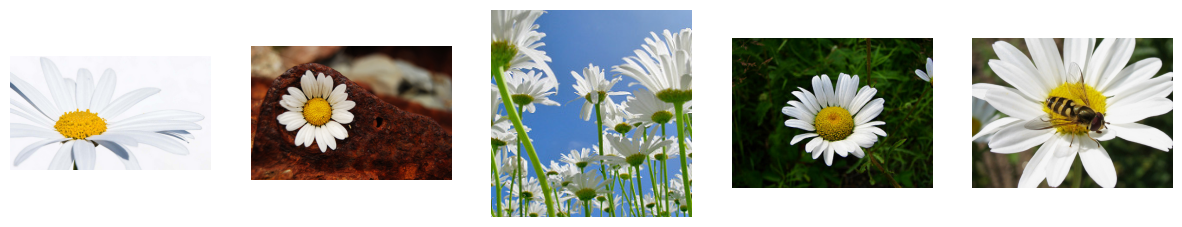

In [ ]:
# Let's look into only "daisy" subfolder
daisies = list(data_dir.glob('daisy/*'))
#PIL.Image.open(roses[1])
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(daisies[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

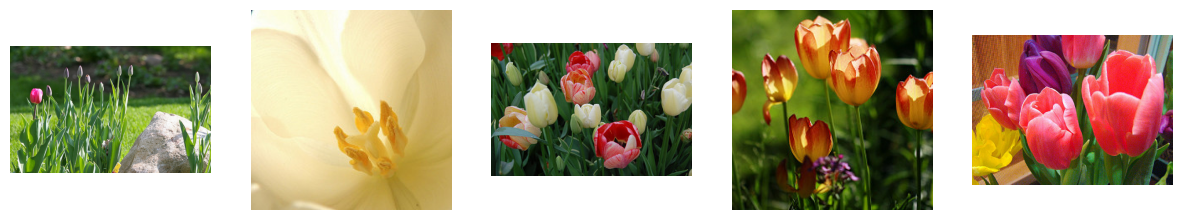

In [ ]:
# Display some tulips
tulips = list(data_dir.glob('tulips/*'))
# Display the first 5 images from the list
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    img = mpimg.imread(tulips[i])
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [ ]:
# Create a dataset for ML model
# Parameters, Set image size and number of images in each batch
batch_size = 32 # batch size of 128
img_height = 224 #180
img_width = 224 #180

In [ ]:
# Data preprocessing
# Generates a tf.data.Dataset from image files in a directory by using tf.keras.preprocessing.image_dataset_from_directory.
# It automatically loads images, assigns labels, resizes them, batches them, and creates a training dataset.
# The tf.keras.preprocessing.image_dataset_from_directory() utility function in TensorFlow is used to generate a tf.data.Dataset object from image files organized in a directory structure.

# Split the image dataset into 8:2. Use 80% of the images for training, and 20% for validation
# Training data set
train_ds = tf.keras.preprocessing.image_dataset_from_directory( # https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123, # Endure reproducibiliy. Without this Every run may create a different random split.
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
# Count images per class from train_ds
# Get class names (folder names in order of labels)
class_names = train_ds.class_names
print("Class names:", class_names)

# Initialize counter
counter = Counter()

# Loop through all batches in train_ds
for images, labels in train_ds:
    counter.update(labels.numpy())

# Display counts
total = 0
print("\nNumber of images per class in TRAINING set:")
for i, class_name in enumerate(class_names):
    count = counter[i]
    total += count
    print(f"{class_name:12s}: {count} images")

print("\nTotal training images:", total)

Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of images per class in TRAINING set:
daisy       : 504 images
dandelion   : 722 images
roses       : 521 images
sunflowers  : 547 images
tulips      : 642 images

Total training images: 2936


In [ ]:
# validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
# Count images per class from val_ds
# Get class names (folder names in order of labels)
class_names = val_ds.class_names
print("Class names:", class_names)

# Initialize counter
counter = Counter()

# Loop through all batches in train_ds
for images, labels in val_ds:
    counter.update(labels.numpy())

# Display counts
total = 0
print("\nNumber of images per class in Validation set:")
for i, class_name in enumerate(class_names):
    count = counter[i]
    total += count
    print(f"{class_name:12s}: {count} images")

print("\nTotal validation images:", total)

Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of images per class in Validation set:
daisy       : 129 images
dandelion   : 176 images
roses       : 120 images
sunflowers  : 152 images
tulips      : 157 images

Total validation images: 734


In [ ]:
# check the class names in the class_names attribute on these datasets
class_names = train_ds.class_names
print(class_names)
val_class_names = val_ds.class_names
print(val_class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


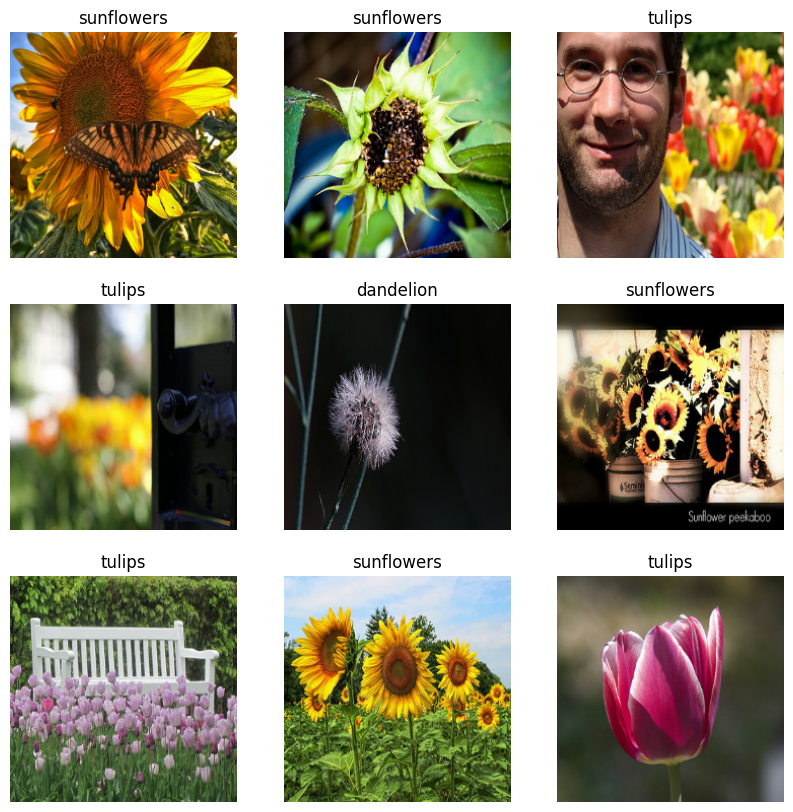

In [ ]:
# Visualize the data
# Show 9 images from train dataset with image labels.
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
# To get information about a numpy array, you can use .shape and .dtype
# The image_batch is a tensor of the shape (32, 180, 180, 3). This is a batch of 32 images of shape 180x180x3 (the last dimension refers to color channels RGB).
# The label_batch is a tensor of the shape (32,), these are corresponding labels to the 32 images.


for image_batch, labels_batch in train_ds:
   print("Shape of image batch:", image_batch.shape)
   print("Data type of image batch:", image_batch.dtype)
   print("Shape of label batch:", labels_batch.shape)
   print("Data type of label batch:", labels_batch.dtype)
   break


Shape of image batch: (32, 224, 224, 3)
Data type of image batch: <dtype: 'float32'>
Shape of label batch: (32,)
Data type of label batch: <dtype: 'int32'>


In [ ]:
# Configure the dataset for performance
# This block is not about learning, but about making the CNN training much faster and more efficient by optimizing the data input pipeline. This is a performance optimization pipeline using TensorFlow’s tf.data API.
# Use buffered prefetching to yield data from disk without having I/O become blocking
# Dataset.cache() keeps the images in memory after they're loaded off disk during the first epoch.
# This will ensure the dataset does not become a bottleneck while training your model.
# Dataset.prefetch() overlaps data preprocessing and model execution while training.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Standardize the data
# Preprocess images by normalizing the pixel values to be in the [0, 1] range (originally all values are in the [0, 255] range).
# All images will be rescaled by 1./255 (min-max normalization)
# Without normalization, Gradients can explode or vanish, and Training becomes slower and unstable

# Take one batch (1st) from the training dataset
image_batch, labels_batch = next(iter(train_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print("Before Normalization: ",np.min(first_image), np.max(first_image))

# Rescaling layer (min-max)
normalization_layer = layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# Take one batch (1st) from the normalized dataset
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print("After Normalization: ", np.min(first_image), np.max(first_image))

Before Normalization:  0.0 255.0
After Normalization:  0.0 0.9998809


In [ ]:
# Create the model

num_classes = 5

alexnet_model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    # Normalize
    # layers.Rescaling(1./255),

    # AlexNet Block 1
    # Conv: 11x11, stride 4, no padding, ReLU
    layers.Conv2D(96, kernel_size=11, strides=4, padding="valid", activation="relu"),
    # Overlapping max pooling: 3x3, stride 2 (AlexNet style)
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # AlexNet Block 2
    # Conv: 5x5, stride 1, padding 2, ReLU
    layers.ZeroPadding2D(padding=2),
    layers.Conv2D(256, kernel_size=5, strides=1, padding= "valid", activation="relu"),
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # AlexNet Block 3-5 (stacked 3x3 convs)
    layers.Conv2D(384, kernel_size=3, padding="same", activation="relu"), # a 3x3 convolution with a stride of 1, "same" padding does mean a padding amount of 1 (padding=1).
    layers.ZeroPadding2D(padding=1),
    layers.Conv2D(384, kernel_size=3, padding= "valid", activation="relu"),
    layers.Conv2D(256, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # Classifier head
    layers.Flatten(),
    layers.Dense(4096, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4096, activation="relu"),
    layers.Dropout(0.5),

    # Output logits (NO softmax here)
    layers.Dense(num_classes)
])

In [ ]:
# Model summary
alexnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 30, 30, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 14, 14, 384)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
# Using the optimizers as Adam optimizer and losses, SparseCategoricalCrossentropy loss function.
# To view training and validation accuracy for each training epoch, pass the metrics argument.

alexnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # a bit smaller LR is often safer for big models
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [ ]:
# Train the model
epochs = 10
history = alexnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=2
)

Epoch 1/10
92/92 - 29s - 313ms/step - accuracy: 0.3641 - loss: 2.6494 - val_accuracy: 0.4605 - val_loss: 1.2021
Epoch 2/10
92/92 - 5s - 50ms/step - accuracy: 0.5184 - loss: 1.1453 - val_accuracy: 0.5504 - val_loss: 1.0524
Epoch 3/10
92/92 - 5s - 49ms/step - accuracy: 0.5702 - loss: 1.0545 - val_accuracy: 0.6172 - val_loss: 0.9807
Epoch 4/10
92/92 - 4s - 49ms/step - accuracy: 0.6352 - loss: 0.9443 - val_accuracy: 0.6485 - val_loss: 0.8772
Epoch 5/10
92/92 - 4s - 49ms/step - accuracy: 0.6638 - loss: 0.8757 - val_accuracy: 0.6621 - val_loss: 0.8284
Epoch 6/10
92/92 - 4s - 48ms/step - accuracy: 0.7136 - loss: 0.7721 - val_accuracy: 0.6553 - val_loss: 0.8811
Epoch 7/10
92/92 - 4s - 48ms/step - accuracy: 0.7296 - loss: 0.7182 - val_accuracy: 0.7221 - val_loss: 0.7262
Epoch 8/10
92/92 - 4s - 48ms/step - accuracy: 0.7428 - loss: 0.6683 - val_accuracy: 0.6308 - val_loss: 0.9107
Epoch 9/10
92/92 - 4s - 47ms/step - accuracy: 0.7868 - loss: 0.5811 - val_accuracy: 0.7234 - val_loss: 0.7477
Epoch 10

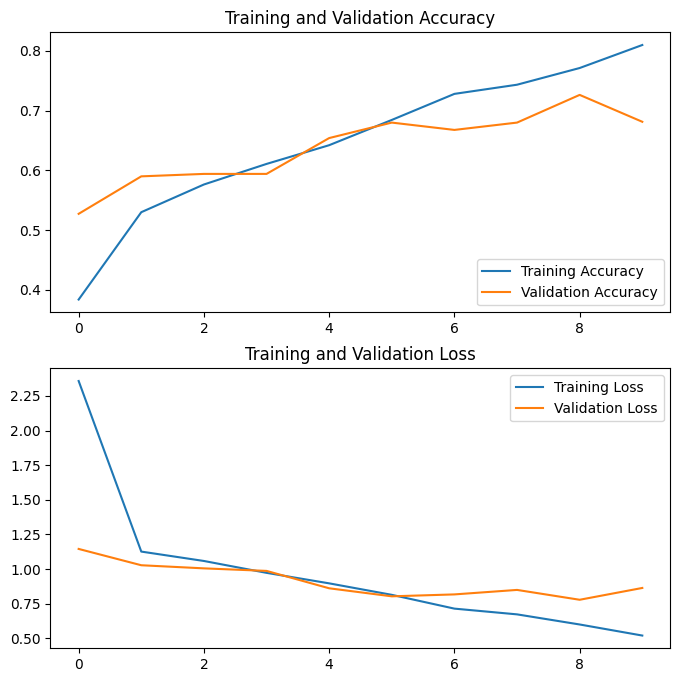

In [ ]:
# Visualize training results
# Create plots of loss and accuracy on the training and validation sets

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [ ]:
# print maximun accuracy on traning and validation data
# In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 60% in the training process.
# Also, the difference in accuracy between training and validation accuracy is noticeable—a sign of overfitting.

print("Training Data Accuracy:",max(acc))
print("Validation Data Accuracy",max(val_acc))

Training Data Accuracy: 0.8096048831939697
Validation Data Accuracy 0.7261580228805542


## Optional(LPN)!


In [ ]:
# Create the model

num_classes = 5

alexnet_model2 = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    # Normalize
    # layers.Rescaling(1./255),

    # AlexNet Block 1
    # Conv: 11x11, stride 4, no padding, ReLU
    layers.Conv2D(96, kernel_size=11, strides=4, padding="valid"),
    layers.BatchNormalization(),
    layers.ReLU(),
    # Overlapping max pooling: 3x3, stride 2 (AlexNet style)
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # AlexNet Block 2
    # Conv: 5x5, stride 1, padding 2, ReLU
    layers.ZeroPadding2D(padding=2),
    layers.Conv2D(256, kernel_size=5, strides=1, padding= "valid"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # AlexNet Block 3-5 (stacked 3x3 convs)
    layers.Conv2D(384, kernel_size=3, padding="same", activation="relu"), # a 3x3 convolution with a stride of 1, "same" padding does mean a padding amount of 1 (padding=1).
    layers.ZeroPadding2D(padding=1),
    layers.Conv2D(384, kernel_size=3, padding= "valid", activation="relu"),
    layers.Conv2D(256, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # Classifier head
    layers.Flatten(),
    layers.Dense(4096, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4096, activation="relu"),
    layers.Dropout(0.5),

    # Output logits (NO softmax here)
    layers.Dense(num_classes)
])

In [ ]:
# Model summary
alexnet_model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_2                │ (None, 30, 30, 96)     │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_3                │ (None, 14, 14, 384)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,768,901 (178.41 MB)

 Trainable params: 46,768,197 (178.41 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Compile the model
# Using the optimizers as Adam optimizer and losses, SparseCategoricalCrossentropy loss function.
# To view training and validation accuracy for each training epoch, pass the metrics argument.

alexnet_model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # a bit smaller LR is often safer for big models
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [ ]:
# Train the model
epochs = 10
history2 = alexnet_model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=2
)

Epoch 1/10
92/92 - 18s - 192ms/step - accuracy: 0.4530 - loss: 1.3145 - val_accuracy: 0.2507 - val_loss: 3.3209
Epoch 2/10
92/92 - 5s - 53ms/step - accuracy: 0.5926 - loss: 1.0220 - val_accuracy: 0.5463 - val_loss: 1.0996
Epoch 3/10
92/92 - 5s - 52ms/step - accuracy: 0.6451 - loss: 0.8989 - val_accuracy: 0.5572 - val_loss: 1.1243
Epoch 4/10
92/92 - 5s - 52ms/step - accuracy: 0.6945 - loss: 0.7855 - val_accuracy: 0.5913 - val_loss: 1.1528
Epoch 5/10
92/92 - 5s - 52ms/step - accuracy: 0.7187 - loss: 0.7214 - val_accuracy: 0.6485 - val_loss: 0.8466
Epoch 6/10
92/92 - 5s - 54ms/step - accuracy: 0.7554 - loss: 0.6480 - val_accuracy: 0.7071 - val_loss: 0.7443
Epoch 7/10
92/92 - 5s - 50ms/step - accuracy: 0.7817 - loss: 0.5653 - val_accuracy: 0.7425 - val_loss: 0.7078
Epoch 8/10
92/92 - 5s - 50ms/step - accuracy: 0.8089 - loss: 0.4861 - val_accuracy: 0.5259 - val_loss: 1.4546
Epoch 9/10
92/92 - 5s - 50ms/step - accuracy: 0.8471 - loss: 0.4141 - val_accuracy: 0.7316 - val_loss: 0.8066
Epoch 10

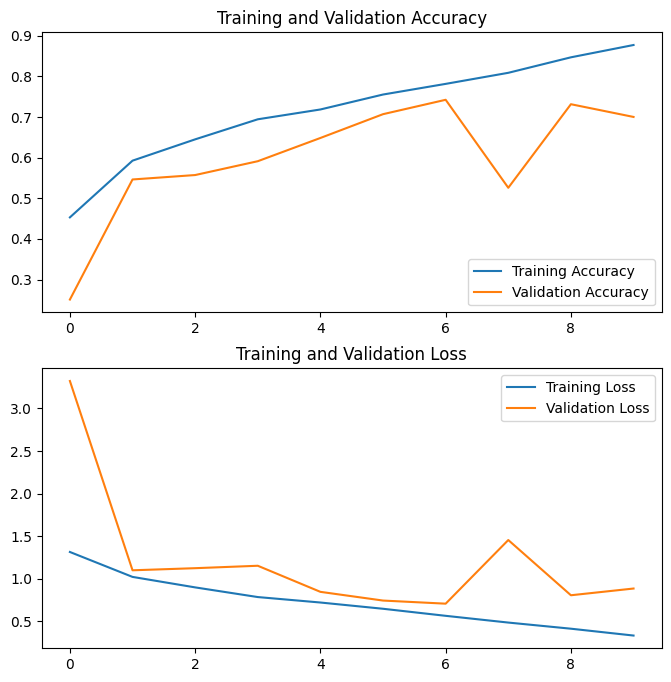

In [ ]:
# Visualize training results
# Create plots of loss and accuracy on the training and validation sets

acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [ ]:
# print maximun accuracy on traning and validation data
# In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 60% in the training process.
# Also, the difference in accuracy between training and validation accuracy is noticeable—a sign of overfitting.

print("Training Data Accuracy:",max(acc))
print("Validation Data Accuracy",max(val_acc))

Training Data Accuracy: 0.8773841857910156
Validation Data Accuracy 0.7425068020820618


# What can we do to tackle overfitting issues?

AlexNet heavily utilized data augmentation specifically to combat severe overfitting due to its 60 million parameters. The techniques, which included random cropping, horizontal flipping, and PCA-based color alterations, artificially increased the dataset size, allowing the model to generalize better.

In [ ]:
data_augmentation_alexnet = tf.keras.Sequential([
    # Random horizontal flip (AlexNet used this)
    layers.RandomFlip("horizontal"),
    # Random crop-like behavior (resize slightly bigger then crop back)
    layers.Resizing(img_height + 20, img_width + 20),
    layers.RandomCrop(img_height, img_width),

    # Color jittering (AlexNet-style RGB intensity changes)
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),

    # Ensure final output is exactly img_height x img_width
    layers.Resizing(img_height, img_width)
], name="alexnet_augmentation")

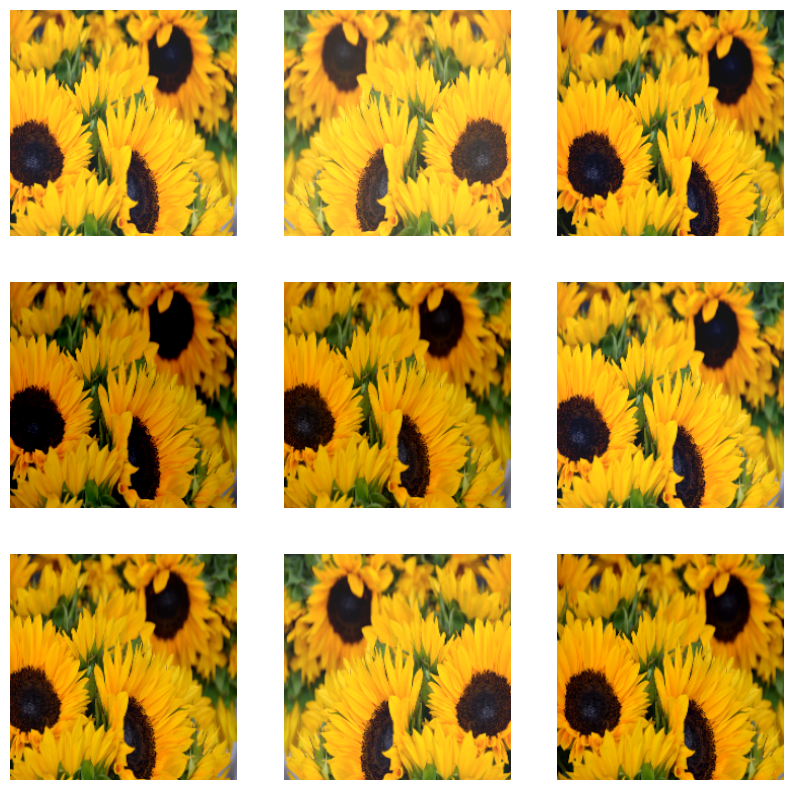

In [ ]:
# Let's visualize what a few augmented examples look like by applying data augmentation to the same image several times

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation_alexnet(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
# Re design the same model with dropout layer
# Dropout
# When we apply Dropout to a layer it randomly drops out (by setting the activation to zero) a number of output units from the layer during the training process.
# Create a new neural network using layers.Dropout, then train it using augmented images.

# Create the model

num_classes = 5

alexnet_model3 = Sequential([
    layers.Input(shape=(img_height, img_width, 3)), # Explicitly define input layer
    data_augmentation_alexnet,

    # Normalize (not needed here as data augmentation handles it implicitly, or can be added explicitly if needed)
    # layers.Rescaling(1./255),

    # AlexNet Block 1
    # Conv: 11x11, stride 4, no padding, ReLU
    layers.Conv2D(96, kernel_size=11, strides=4, padding="valid"),
    layers.BatchNormalization(),
    layers.ReLU(),
    # Overlapping max pooling: 3x3, stride 2 (AlexNet style)
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # AlexNet Block 2
    # Conv: 5x5, stride 1, padding 2, ReLU
    layers.ZeroPadding2D(padding=2),
    layers.Conv2D(256, kernel_size=5, strides=1, padding= "valid"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # AlexNet Block 3-5 (stacked 3x3 convs)
    layers.Conv2D(384, kernel_size=3, padding="same", activation="relu"), # a 3x3 convolution with a stride of 1, "same" padding does mean a padding amount of 1 (padding=1).
    layers.ZeroPadding2D(padding=1),
    layers.Conv2D(384, kernel_size=3, padding= "valid", activation="relu"),
    layers.Conv2D(256, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=3, strides=2, padding="valid"),

    # Classifier head
    layers.Flatten(),
    layers.Dense(4096, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4096, activation="relu"),
    layers.Dropout(0.5),

    # Output logits (NO softmax here)
    layers.Dense(num_classes)
])

In [ ]:
alexnet_model3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ alexnet_augmentation            │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_14               │ (None, 30, 30, 96)     │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_15               │ (None, 14, 14, 384)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,768,901 (178.41 MB)

 Trainable params: 46,768,197 (178.41 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:

# Compile the model
# Using the optimizers as Adam optimizer and losses, SparseCategoricalCrossentropy loss function.
# To view training and validation accuracy for each training epoch, pass the metrics argument.

alexnet_model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # a bit smaller LR is often safer for big models
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [ ]:
# Train the model
epochs = 10
history3 = alexnet_model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=2
)

Epoch 1/10
92/92 - 10s - 113ms/step - accuracy: 0.4326 - loss: 1.3633 - val_accuracy: 0.4523 - val_loss: 1.4439
Epoch 2/10
92/92 - 7s - 76ms/step - accuracy: 0.5674 - loss: 1.0677 - val_accuracy: 0.4959 - val_loss: 1.2664
Epoch 3/10
92/92 - 7s - 77ms/step - accuracy: 0.6042 - loss: 0.9930 - val_accuracy: 0.5940 - val_loss: 0.9849
Epoch 4/10
92/92 - 7s - 76ms/step - accuracy: 0.6546 - loss: 0.8956 - val_accuracy: 0.6349 - val_loss: 0.9162
Epoch 5/10
92/92 - 7s - 75ms/step - accuracy: 0.6890 - loss: 0.8116 - val_accuracy: 0.5940 - val_loss: 1.0922
Epoch 6/10
92/92 - 7s - 75ms/step - accuracy: 0.6952 - loss: 0.7697 - val_accuracy: 0.6676 - val_loss: 0.8446
Epoch 7/10
92/92 - 7s - 74ms/step - accuracy: 0.7190 - loss: 0.7297 - val_accuracy: 0.6308 - val_loss: 0.9634
Epoch 8/10
92/92 - 7s - 74ms/step - accuracy: 0.7469 - loss: 0.6793 - val_accuracy: 0.6757 - val_loss: 0.8751
Epoch 9/10
92/92 - 7s - 74ms/step - accuracy: 0.7452 - loss: 0.6565 - val_accuracy: 0.7180 - val_loss: 0.6970
Epoch 10

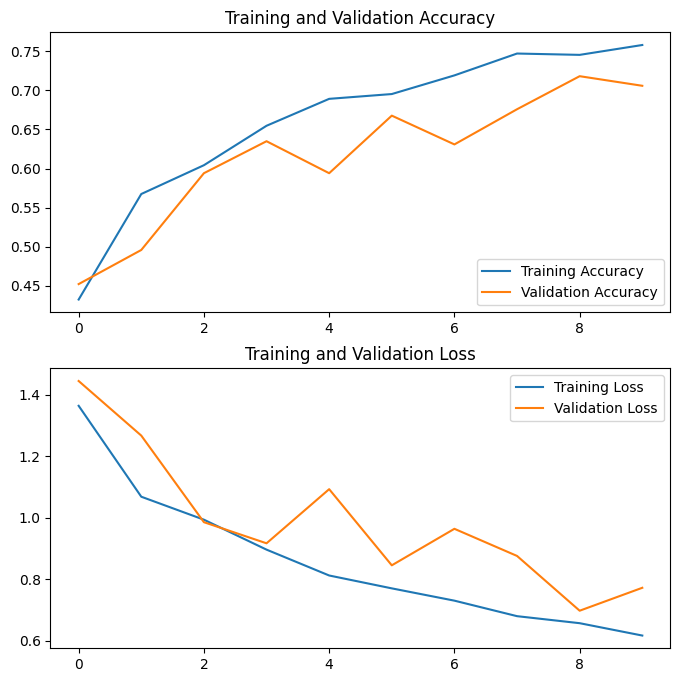

In [ ]:
# After applying data augmentation and Dropout, there is less overfitting than before, and training and validation accuracy are closer aligned

acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']

loss = history3.history['loss']
val_loss = history3.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Diplay basic statistics
import statistics as st
print("The maximum training Data Accuracy:",max(acc))
print("The maximum validation Data Accuracy",max(val_acc))
print("Average training Data Accuracy:",st.mean(acc))
print("Average validation Data Accuracy",st.mean(val_acc))

The maximum training Data Accuracy: 0.7578337788581848
The maximum validation Data Accuracy 0.7179836630821228
Average training Data Accuracy: 0.6612057238817215
Average validation Data Accuracy 0.6168937385082245


In [ ]:
# Predict on new data
# Note: Data augmentation and Dropout layers are inactive at inference time.

sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = keras.preprocessing.image.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch (of zero)

predictions = alexnet_model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
This image most likely belongs to tulips with a 65.94 percent confidence.
